In [1]:
import pandas as pd
import torch
import transformers
from torch.utils.data import Dataset
import os
import numpy as np
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

/blue/egn6933/share/apatil2/conda/envs/pathogen_new1/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
combined = pd.read_csv('combined_df.csv')

### Adding the region column in the dataframe, 'combined'

In [2]:
noncoding = pd.read_csv('/home/apatil2/Disease_risk_modeling/filtered_data_link/data/clinvar_20240805.noncoding.txt',
                sep = '\t',
                low_memory = False)

coding = pd.read_csv('/home/apatil2/Disease_risk_modeling/filtered_data_link/clinvar_20240805.missense_matched.txt',
                sep = '\t',
                low_memory = False)

In [6]:
#filtering the unwanted columns
coding_small = coding[['CHROM', 'POS', 'REF', 'ALT', 'Pathogenicity']]
noncoding_small = noncoding[['CHROM', 'POS', 'REF', 'ALT', 'Pathogenicity']]


In [8]:
combined.head()

,CHROM,POS,REF,ALT,Pathogenicity
0,14,64049723,C,T,0
1,4,102674046,T,C,0
2,3,14148544,C,T,0
3,6,7566402,A,G,0
4,8,144442058,T,C,0


In [9]:
noncoding_small.head(), noncoding_small.shape

(  CHROM      POS REF ALT Pathogenicity
 0     1  1020383   C   T             B
 1     1  1020390   C   T             B
 2     1  1020391   C   G             B
 3     1  1020392   C   T             B
 4     1  1020392   C   G             B,
 (95760, 5))

In [10]:
noncoding_variants = [(row['CHROM'], row['POS']) for i, row in noncoding_small.iterrows()]

In [94]:
noncoding_variants_label = []
for index, row in combined.iterrows():
    # print(type(row['CHROM']))
    s = (row['CHROM'], row['POS'])
    if s in noncoding_variants:
        noncoding_variants_label.append(1)
    else:
        noncoding_variants_label.append(0)
    # break

In [95]:
#saving the dataframe with the region column
combined['region'] = noncoding_variants_label
combined.to_csv('combined_df_regions.csv')

In [2]:
combined = pd.read_csv('combined_df_regions.csv')

In [3]:
combined.drop(columns={'Unnamed: 0'}, inplace=True)

In [4]:
pos = (combined['Pathogenicity']==1).sum()
neg = (combined['Pathogenicity']==0).sum()

pos/neg

np.float64(0.06861190761905023)

In [5]:
folder = '/blue/egn6933/apatil2/embeddings/'

files = sorted([f for f in os.listdir(folder) if f.endswith('.pt')])

train_files, test_files = train_test_split(
    files,
    test_size=0.2,
    random_state=42
)

print(len(train_files), len(test_files))

2444 611


In [6]:
#function to extract the starting index
def get_file_idx(f):
    return int(f.split('_')[-1].replace('.pt',''))

In [7]:
#saving the indices in the test set in a list
test_indices = []
start_indices = []
for f in test_files:
    start = get_file_idx(f)
    end = start+256
    test_indices.extend(range(start, end))
    start_indices.append(int(f.split('_')[-1].replace('.pt','')))

In [8]:
#filtering out the test rows from the main dataframe
combined_test = combined.iloc[test_indices].reset_index(drop=True)

In [9]:
# define the dataset class
class EmbeddingDataset(Dataset):
    
    def __init__(self, folder, files):
        self.folder = folder
        self.files = files
    
    def __len__(self):
        
        return len(self.files)
    
    def __getitem__(self, idx):
        
        batch = torch.load(os.path.join(self.folder, self.files[idx]))
        X = batch['X'][:, 64, :]
        y = batch['Y']
        
        return X, y                        

In [10]:
# define the data loader

train_dataset = EmbeddingDataset(folder, train_files)

test_dataset = EmbeddingDataset(folder, test_files)

train_loader = DataLoader(train_dataset, batch_size = 1, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 1, shuffle = False)

In [11]:
import torch.nn as nn

class MLP(nn.Module):
    
    def __init__(self):
        super().__init__()
    
        self.model = nn.Sequential(
            nn.Linear(768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        x = torch.nn.functional.normalize(x, dim=1)
        return self.model(x)
    

In [12]:
#complex model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model1 = MLP().to(device)

#using weighted loss function
weights = torch.sqrt(torch.tensor([neg/pos])).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight = weights)

#early stopping threshold
threshold = 1e-3
prev_loss = float('inf')
patience = 3
patience_counter = 0

initial_rate = 1e-4
optimizer = torch.optim.Adam(
    model1.parameters(),
    lr = initial_rate
)

scheduler = lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.1)

epoch = 50

In [13]:
def compute_accuracy(preds, labels):
    preds = torch.sigmoid(preds)
    preds = (preds>0.5).float()
    
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    
    return correct, total

In [14]:
def compute_precision(preds, labels):
    preds = torch.sigmoid(preds)
    preds = (preds>0.5).float()
    
    true_positive = ((preds==1.0) & (labels==1.0)).sum().item()
    false_positive = ((preds==1.0) & (labels==0.0)).sum().item()
    
    return true_positive, false_positive

In [15]:
def compute_recall(preds, labels):
    preds = torch.sigmoid(preds)
    preds = (preds>0.5).float()
    
    false_negative = ((preds==0.0) & (labels==1.0)).sum().item()
    return false_negative

In [18]:
# training loop

# model.train()
train_loss = []
train_acc = []
train_precision = []
train_recall = []

for i in range(epoch):
    model1.train()
    total_correct = 0
    total_samples = 0
    total_loss = 0
    total_true_positive = 0
    total_false_positive = 0
    total_false_negative = 0
    
    for X,y in train_loader:
        
        #reshaping the input embeddings and converting the labels to float
        X = X.squeeze().to(device)
        y = y.squeeze().float().to(device)
        
        #setting the previous gradients to zero
        optimizer.zero_grad()
        
        #getting the output from the model
        output = model1(X).squeeze()
        
        #calculating the loss
        loss = criterion(output, y)
        
        #backpropagation step
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        #computing the accuracy 
        correct, total = compute_accuracy(output, y)
        total_correct += correct
        total_samples += total
        
        #computing the precision 
        true_positive, false_positive = compute_precision(output, y)
        total_true_positive += true_positive
        total_false_positive += false_positive
        
        #computing the recall 
        false_negative = compute_recall(output, y)
        total_false_negative += false_negative
        

    #updating the learning rate
    scheduler.step()
    
    #metrics calculation per epoch
    epoch_acc = total_correct / total_samples
    epoch_precision = total_true_positive/(total_true_positive+total_false_positive)
    epoch_recall = total_true_positive/(total_true_positive+total_false_negative)
    epoch_loss = total_loss/len(train_loader)
    
    #storing the metrics as per the epoch
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc)
    train_precision.append(epoch_precision)
    train_recall.append(epoch_recall)
    print(f"Epoch {i+1} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f} | Precision: {epoch_precision:.4f} | Recall: {epoch_recall:.4f}")
    
    #saving the model
    torch.save(
        model1.state_dict(),
        f"/blue/egn6933/apatil2/model_checkpoints/complex_model_2/model_epoch_{i+1}.pt"
    )
    
    #early stopping logic
    if abs(prev_loss-epoch_loss)<threshold:
        patience_counter += 1
    
    else:
        patience_counter = 0
        
    if patience_counter>patience:
        print('Stopping early: converged')
        break
    
    prev_loss = epoch_loss



Epoch 1 | Loss: 0.4918 | Accuracy: 0.9150 | Precision: 0.3046 | Recall: 0.2503
Epoch 2 | Loss: 0.4602 | Accuracy: 0.9100 | Precision: 0.3250 | Recall: 0.3704
Epoch 3 | Loss: 0.4478 | Accuracy: 0.9092 | Precision: 0.3321 | Recall: 0.4071
Epoch 4 | Loss: 0.4387 | Accuracy: 0.9094 | Precision: 0.3392 | Recall: 0.4316
Epoch 5 | Loss: 0.4300 | Accuracy: 0.9105 | Precision: 0.3499 | Recall: 0.4578
Epoch 6 | Loss: 0.4228 | Accuracy: 0.9112 | Precision: 0.3573 | Recall: 0.4768
Epoch 7 | Loss: 0.4156 | Accuracy: 0.9120 | Precision: 0.3631 | Recall: 0.4888
Epoch 8 | Loss: 0.4086 | Accuracy: 0.9126 | Precision: 0.3694 | Recall: 0.5073
Epoch 9 | Loss: 0.4020 | Accuracy: 0.9128 | Precision: 0.3739 | Recall: 0.5273
Epoch 10 | Loss: 0.3961 | Accuracy: 0.9142 | Precision: 0.3809 | Recall: 0.5354
Epoch 11 | Loss: 0.3898 | Accuracy: 0.9155 | Precision: 0.3886 | Recall: 0.5480
Epoch 12 | Loss: 0.3839 | Accuracy: 0.9162 | Precision: 0.3932 | Recall: 0.5581
Epoch 13 | Loss: 0.3775 | Accuracy: 0.9166 | Prec

In [18]:
#saving the training results
d = {
     'loss': train_loss, 
     'accuracy': train_acc,
     'precision': train_precision,
     'recall': train_recall
    }

train_results = pd.DataFrame(d)
train_results.to_csv('train_results_2.csv')

In [16]:
train_result = pd.read_csv('train_results_2.csv')

In [17]:
train_result.head()

,Unnamed: 0,loss,accuracy,precision,recall
0,0,0.491808,0.915044,0.304553,0.250329
1,1,0.460224,0.910047,0.324978,0.370434
2,2,0.447834,0.909229,0.332076,0.407112
3,3,0.438738,0.909389,0.339177,0.431555
4,4,0.429977,0.910455,0.349927,0.457789


In [18]:
train_result.drop(columns={'Unnamed: 0'}, inplace=True)

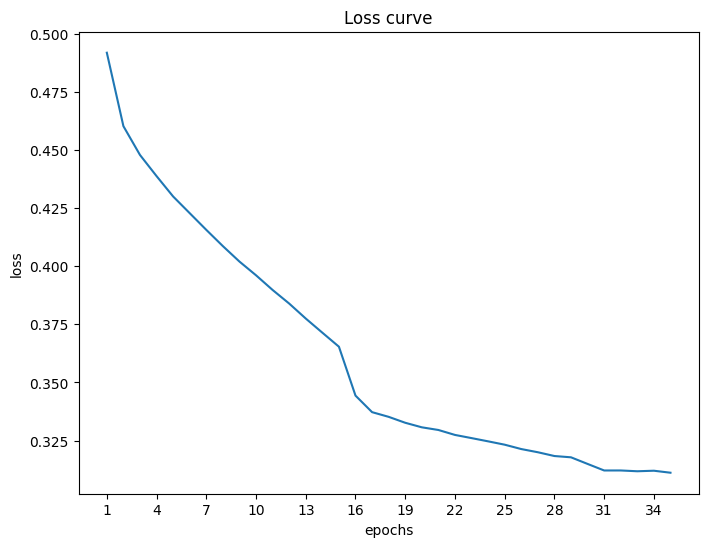

<Figure size 640x480 with 0 Axes>

In [19]:
#plotting loss curve for training

x = np.arange(1,36)
y = train_result['loss']

plt.figure(figsize=(8,6))
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Loss curve')
plt.xticks(np.arange(1,36,3))
plt.plot(x, y, label='Loss curve')
plt.show()
plt.savefig('plots/Train loss curve_2.png')

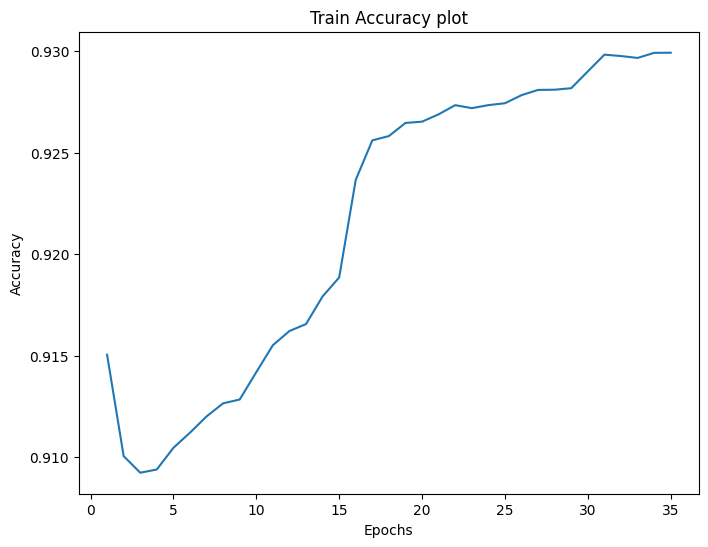

In [44]:
#plotting the accuracy curve

plt.figure(figsize=(8,6))

x = np.arange(1,36,1)
y = train_result['accuracy']

plt.plot(x, y )
plt.title('Train Accuracy plot')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [43]:
#Load the saved model weights
path = '/blue/egn6933/apatil2/model_checkpoints/complex_model_2/model_epoch_35.pt'

checkpoint = torch.load(path)


In [44]:
#load the parameters into the MLP instance
model1.load_state_dict(checkpoint)

<All keys matched successfully>

In [45]:
# model evaluation loop
model1.eval()

predictions = []
true_labels = []

test_samples = 0
correct_samples = 0
with torch.no_grad():
    
    test_loss = 0.0
    total_true_positive = 0.0
    total_false_positive = 0.0
    total_false_negative = 0.0
    for X, y in test_loader:
        # print(X.shape, y.shape)
        X = X.squeeze().to(device)
        y = y.squeeze().float().to(device)
        
        outputs = model1(X).squeeze()
        probs = torch.sigmoid(outputs)
        
        predictions.extend(probs.cpu().numpy())
        true_labels.extend(y.cpu().numpy())
        
        test_loss += criterion(outputs, y).item()
        
        correct, total = compute_accuracy(outputs, y)
        correct_samples+=correct
        test_samples+=total
        
        true_positive, false_positive = compute_precision(outputs, y)
        total_true_positive += true_positive
        total_false_positive += false_positive
        
        false_negative = compute_recall(outputs, y)
        total_false_negative += false_negative
        # total
    
    val_acc = correct_samples/test_samples
    val_loss = test_loss/len(test_loader)
    val_precision = total_true_positive/(total_true_positive+total_false_positive)
    val_recall = total_true_positive/(total_true_positive+total_false_negative)
    
    print(f'The test accuracy is: {val_acc} | test loss is: {val_loss} | precision is: {val_precision} | recall is: {val_recall}')
        


The test accuracy is: 0.9195095130932897 | test loss is: 0.4126273194623657 | precision is: 0.40309615957130096 | recall is: 0.542359303024234


In [46]:
y_true = np.array(true_labels)
y_probs = np.array(predictions)

In [47]:
regions = combined_test['region'].values

In [48]:
regions.shape

(156416,)

In [49]:
coding_idx = regions==0
noncoding_idx = regions==1

In [50]:
from sklearn.metrics import roc_curve, auc

fpr_c, tpr_c, _ = roc_curve(y_true[coding_idx], y_probs[coding_idx])
auc_c = auc(fpr_c, tpr_c)

In [51]:
fpr_nc, tpr_nc,_ = roc_curve(y_true[noncoding_idx], y_probs[noncoding_idx])
auc_nc = auc(fpr_nc, tpr_nc)

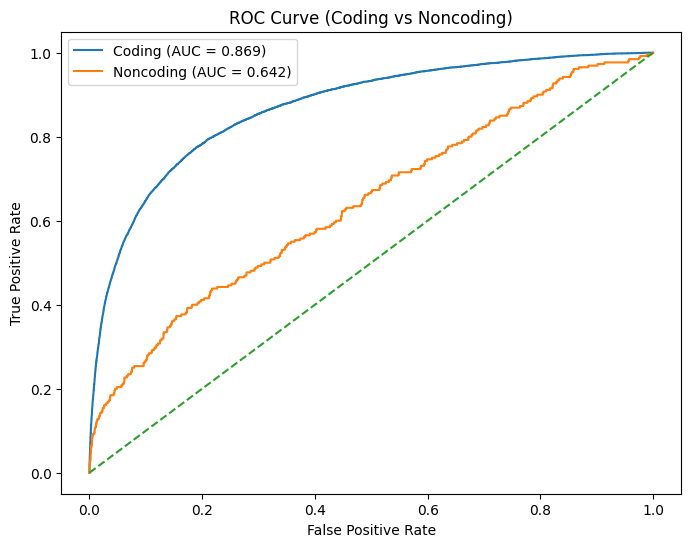

<Figure size 640x480 with 0 Axes>

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.plot(fpr_c, tpr_c, label=f'Coding (AUC = {auc_c:.3f})')
plt.plot(fpr_nc, tpr_nc, label=f'Noncoding (AUC = {auc_nc:.3f})')

plt.plot([0,1], [0,1], linestyle='--')  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Coding vs Noncoding)")
plt.legend()

plt.show()
plt.savefig('plots/Regionic_ROC_2.png')

In [53]:
m1 = {'true': true_labels, 'preds': predictions}

val_df = pd.DataFrame(m1)

In [54]:
# true_labels

In [55]:
# predictions
val_df

,true,preds
0,0.0,0.007687
1,0.0,0.000285
2,0.0,0.306573
3,0.0,0.007683
4,0.0,0.000916
...,...,...
156411,0.0,0.017446
156412,0.0,0.131692
156413,0.0,0.005350
156414,0.0,0.015416


In [56]:
#plotting the confusion matrix
category = []

for index, row in val_df.iterrows():
    if row['true']==0 and row['preds']<0.5:
        category.append('TN')
    
    elif row['true']==0 and row['preds']>=0.5:
        category.append('FP')
    
    elif row['true']==1 and row['preds']>=0.5:
        category.append('TP')
    
    elif row['true']==1 and row['preds']<0.5:
        category.append('FN')

val_df['category']= category

In [57]:
val_df['category'].value_counts()

category
TN    138410
FP      8020
TP      5416
FN      4570
Name: count, dtype: int64

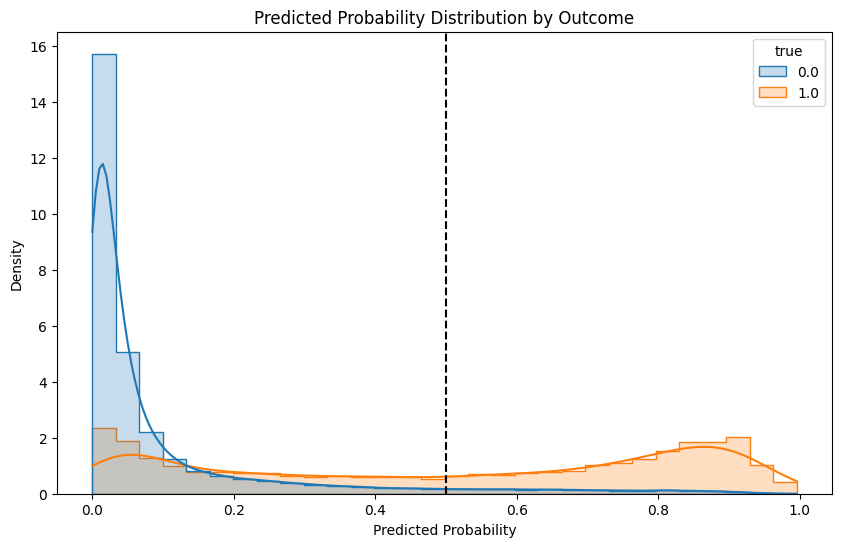

In [58]:
#plotting the confusion matrix
plt.figure(figsize=(10,6))
sns.histplot(data=val_df, x='preds', hue='true',
            element='step', common_norm=False,
            # palette={'TP': 'blue', 'TN': 'green', 
            #           'FP': 'red', 'FN': 'orange'},
             stat='density',
             kde=True, bins=30)
plt.axvline(x=0.5, color='black', linestyle='--')
plt.title('Predicted Probability Distribution by Outcome')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.show()

In [35]:
val_df

,true,preds,category
0,0.0,0.512830,FP
1,0.0,0.512869,FP
2,0.0,0.513084,FP
3,0.0,0.512753,FP
4,0.0,0.512911,FP
...,...,...,...
156411,0.0,0.512888,FP
156412,0.0,0.512859,FP
156413,0.0,0.512779,FP
156414,0.0,0.512783,FP


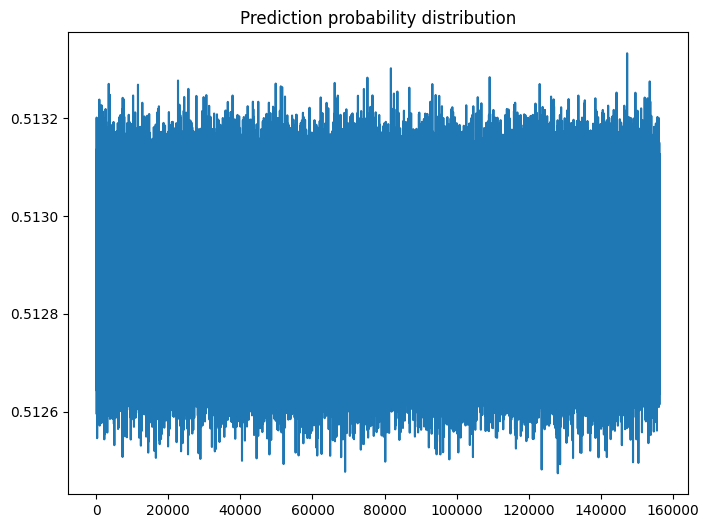

In [42]:
r = np.arange(1, val_df.shape[0]+1, 1)
y = val_df['preds']

plt.figure(figsize=(8,6))
plt.plot(r,y)
plt.title('Prediction probability distribution')
plt.show()
